In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Center near Yamuna River, Delhi: approx 28.60 N, 77.25 E [web:10][web:6]
center_lat, center_lon = 28.60, 77.25

# Grid spacing ~1km apart (0.01 degrees ~1km)
lat_step = 0.009  # ~1km north-south
lon_step = 0.009  # ~1km east-west (river flows north-south, cols left-right)

# Create grid indices
rows = np.arange(10)
cols = np.arange(5)
row_mesh, col_mesh = np.meshgrid(rows, cols, indexing='ij')

# Generate lat/lon
lat = center_lat + (row_mesh - 4.5) * lat_step  # rows 0-9 centered
lon = center_lon + (col_mesh - 2) * lon_step    # cols 0-4, left=river side

# Flatten to 50 cells
cell_id = np.arange(50) + 1
row_flat = row_mesh.flatten()
col_flat = col_mesh.flatten()
lat_flat = lat.flatten()
lon_flat = lon.flatten()

print(f"Generated {len(cell_id)} cells around Yamuna belt")

Generated 50 cells around Yamuna belt


In [5]:
np.random.seed(42)  # Reproducible

# Elevation: 200-220m avg 206m, lower near river (left cols 0-1) [web:6]
base_elev = 206
river_elev_drop = np.array([0.8, 0.6, 0.3, 0.1, 0]) * 15  # drop up to 12m near river
row_elev_vary = np.tile(river_elev_drop, 10) + np.random.normal(0, 2, 50)
elevation_m = np.clip(base_elev + row_elev_vary, 195, 225)

# Drainage poorness 0-1: worse in cols 1,3 (urban poor areas) [web:7][web:12]
drain_base = np.tile([0.2, 0.7, 0.3, 0.8, 0.4], 10)
drainage_poorness = np.clip(drain_base + np.random.normal(0, 0.1, 50), 0, 1)

# Rainfall: heavy July 100-200mm varied [web:8][web:13]
rainfall_mm = np.random.normal(150, 40, 50)
rainfall_mm = np.clip(rainfall_mm, 80, 250)

# DataFrame
df = pd.DataFrame({
    'cell_id': cell_id,
    'row': row_flat,
    'col': col_flat,
    'lat': lat_flat,
    'lon': lon_flat,
    'elevation_m': elevation_m,
    'drainage_poorness': drainage_poorness,
    'rainfall_mm': rainfall_mm
})

print(df.head())
print("\nElevation stats:", df['elevation_m'].describe())
print("Drainage stats:", df['drainage_poorness'].describe())
print("Rainfall stats:", df['rainfall_mm'].describe())

   cell_id  row  col      lat     lon  elevation_m  drainage_poorness  \
0        1    0    0  28.5595  77.232   218.993428           0.232408   
1        2    0    1  28.5595  77.241   214.723471           0.661492   
2        3    0    2  28.5595  77.250   211.795377           0.232308   
3        4    0    3  28.5595  77.259   210.546060           0.861168   
4        5    0    4  28.5595  77.268   205.531693           0.503100   

   rainfall_mm  
0    93.385170  
1   133.174187  
2   136.291419  
3   117.908909  
4   143.548572  

Elevation stats: count     50.000000
mean     210.949052
std        5.316073
min      202.473920
25%      206.322473
50%      211.056210
75%      215.398980
max      220.931298
Name: elevation_m, dtype: float64
Drainage stats: count    50.000000
mean      0.481778
std       0.254941
min       0.053649
25%       0.269334
50%       0.424071
75%       0.734186
max       0.956464
Name: drainage_poorness, dtype: float64
Rainfall stats: count     50.000000
mea

In [7]:
# Normalize 0-1: higher values = higher risk component
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df['rain_norm'] = normalize(df['rainfall_mm'])
df['elev_norm'] = normalize(df['elevation_m'])  # high elev = low risk, but for components we invert later
df['elev_component'] = 1 - df['elev_norm']  # low elev = high risk
df['drain_component'] = df['drainage_poorness']
df['rain_component'] = df['rain_norm']

# Readiness Score (0-100): higher = higher risk/lower readiness [user formula]
df['readiness_score'] = 100 * (
    0.4 * df['rain_component'] + 
    0.35 * df['elev_component'] + 
    0.25 * df['drain_component']
)

# Risk class
def get_risk_class(score):
    if score < 30:
        return 'Low'
    elif score < 70:
        return 'Medium'
    else:
        return 'High'

df['risk_class'] = df['readiness_score'].apply(get_risk_class)

print(df[['cell_id', 'readiness_score', 'risk_class']].head(10))
print("\nScore stats:", df['readiness_score'].describe())
print("Risk distribution:\n", df['risk_class'].value_counts())

   cell_id  readiness_score risk_class
0        1        12.661844        Low
1        2        40.929680     Medium
2        3        36.492376     Medium
3        4        50.219871     Medium
4        5        56.862220     Medium
5        6        34.224967     Medium
6        7        55.181544     Medium
7        8        41.868620     Medium
8        9        67.137327     Medium
9       10        54.602328     Medium

Score stats: count    50.000000
mean     47.246730
std      16.604987
min      11.118090
25%      36.382610
50%      45.774335
75%      59.179718
max      89.734881
Name: readiness_score, dtype: float64
Risk distribution:
 risk_class
Medium    41
Low        6
High       3
Name: count, dtype: int64


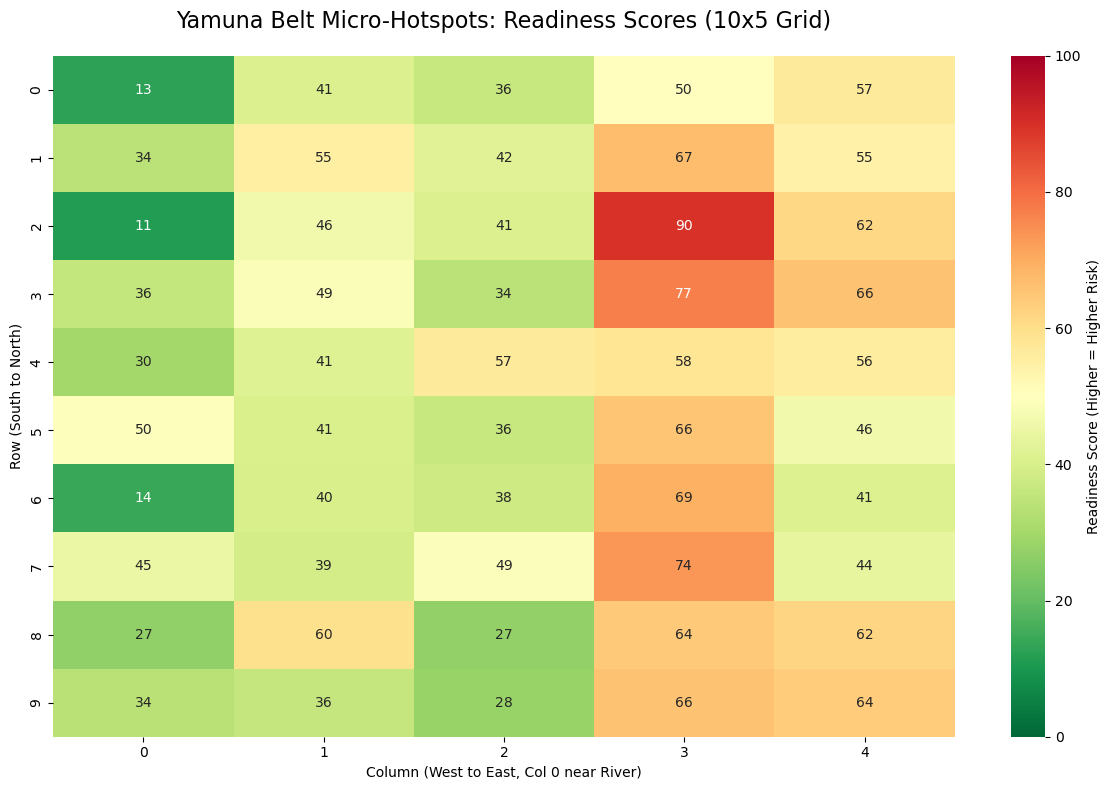

In [9]:
plt.figure(figsize=(12, 8))
pivot_scores = df.pivot(index='row', columns='col', values='readiness_score')
sns.heatmap(pivot_scores, annot=True, fmt='.0f', cmap='RdYlGn_r',  # red high risk, green low
            vmin=0, vmax=100, cbar_kws={'label': 'Readiness Score (Higher = Higher Risk)'})
plt.title('Yamuna Belt Micro-Hotspots: Readiness Scores (10x5 Grid)', fontsize=16, pad=20)
plt.xlabel('Column (West to East, Col 0 near River)')
plt.ylabel('Row (South to North)')
plt.tight_layout()
plt.savefig('readiness_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Base map centered on grid
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='OpenStreetMap')

# Color map for risk
color_map = {'Low': 'green', 'Medium': 'yellow', 'High': 'red'}

# Add CircleMarkers with popups
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8,
        popup=folium.Popup(
            f"<b>Cell {row['cell_id']}</b><br>"
            f"Score: {row['readiness_score']:.1f} ({row['risk_class']})<br>"
            f"Elev: {row['elevation_m']:.1f}m | Drain: {row['drainage_poorness']:.2f}<br>"
            f"Rain: {row['rainfall_mm']:.1f}mm<br>"
            f"Lat/Lon: {row['lat']:.4f}, {row['lon']:.4f}",
            max_width=250
        ),
        color=color_map[row['risk_class']],
        fill=True,
        fillColor=color_map[row['risk_class']],
        fillOpacity=0.7,
        weight=2
    ).add_to(m)

# Save map
m.save('yamuna_folium_map.html')
print("Map saved as 'yamuna_folium_map.html'")
m  # Displays in notebook

Map saved as 'yamuna_folium_map.html'


In [13]:
df.to_csv('yamuna_grid_readiness_scores.csv', index=False)
print("Exported to yamuna_grid_readiness_scores.csv")
print("Shape:", df.shape)
print("\nHigh risk cells:\n", df[df['risk_class']=='High'][['cell_id', 'readiness_score', 'lat', 'lon']].head())

Exported to yamuna_grid_readiness_scores.csv
Shape: (50, 15)

High risk cells:
     cell_id  readiness_score      lat     lon
13       14        89.734881  28.5775  77.259
18       19        77.281135  28.5865  77.259
38       39        73.519731  28.6225  77.259
